In [5]:
import os
os.chdir('/data/doujy/Documents/Code/DynNet')
import itertools
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from scipy import stats
from scipy.stats import gaussian_kde, norm
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import NearestNeighbors
from scipy.optimize import minimize
from tqdm import tqdm  # Import tqdm for progress bar
import scanpy as sc
from matplotlib import rcParams  # Import matplotlib to avoid NameError
from models.dynnet import DynNet
from utils.solver import euler_solver_sde
import shutup

# Set matplotlib parameters
shutup.please()
rcParams['font.family'] = 'Arial'
rcParams['svg.fonttype'] = 'none'
rcParams['svg.fonttype'] = 'none'
rcParams['font.family'] = 'Arial'

# Define colors and labels
colors = {
    'de': '#a2be8e',
    'he': '#d4cb92',
    'heLB': '#f4d092',
    'heLTLB': '#ed7f80',
    'transC4C5': '#f7a072',
    'mh': '#6f739b',
    'ih': '#828fb0',
    'ipsc': '#a2be8e'
}
labels_rename = {
    'de': 'DE',
    'he': 'HE',
    'heLB': 'early LB',
    'heLTLB': 'late LB',
    'transC4C5': 'Transition',
    'mh': 'MH',
    'ih': 'IH',
    'ipsc': 'iPSc'
}

# Check if the file exists
file_path = '/data/doujy/Documents/Code/DynNet/data/Hepatocyte_Development_BF/Hepatocyte_Development_BF.h5ad'
if os.path.exists(file_path):
    print(f"The file {file_path} exists.")
    adata = sc.read_h5ad(file_path)
else:
    print(f"The file {file_path} does not exist.")
    data = pd.read_csv('data.csv', index_col=0)

    # Convert the DataFrame to an AnnData object
    adata = sc.AnnData(data.drop(columns=['cell_id_new', 'cell_id', 'experiment', 'category']))
    adata.obs['cell_id_new'] = data['cell_id_new']
    adata.obs['cell_id'] = data['cell_id']
    adata.obs['experiment'] = data['experiment'].astype('category')
    adata.obs['category'] = data['category'].astype('category')
    adata.uns['colors'] = {
        'category': {key: list(mcolors.to_rgb(color)) for key, color in colors.items()},
        'label': {labels_rename[key]: list(mcolors.to_rgb(color)) for key, color in colors.items()}
    }
    adata.obs['label'] = adata.obs.category.map(labels_rename)
    sc.pp.neighbors(adata)
    sc.tl.umap(adata)
    sc.tl.tsne(adata)

adata_selected = adata[adata.obs['category'] != 'ipsc', :]
model = DynNet(0.1, 1, 1, 20)

The file /data/doujy/Documents/Code/DynNet/data/Hepatocyte_Development_BF/Hepatocyte_Development_BF.h5ad exists.


In [6]:
model.load_state_dict(torch.load(R'./models/checkpoints/Hepatocyte_Development_BF/Hepatocyte_Development_BF.pth'))

data0 = adata[adata.obs['time_point']==0,:].X
data0_label = adata[adata.obs['time_point']==0,:].obs['label']
data1 = adata[adata.obs['time_point']==1,:].X
data1_label = adata[adata.obs['time_point']==1,:].obs['label']
data2 = adata[adata.obs['time_point']==2,:].X
data2_label = adata[adata.obs['time_point']==2,:].obs['label']
data3 = adata[adata.obs['time_point']==3,:].X
data3_label = adata[adata.obs['time_point']==3,:].obs['label']
data = adata.X
color = adata.uns['colors']['label']
y0 = torch.tensor(data0.toarray(), dtype=torch.float32)
yf = torch.tensor(data3.toarray(), dtype=torch.float32)
label_unique = adata.obs['label'].unique()
y0_new = torch.cat((y0,y0),dim=0)


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

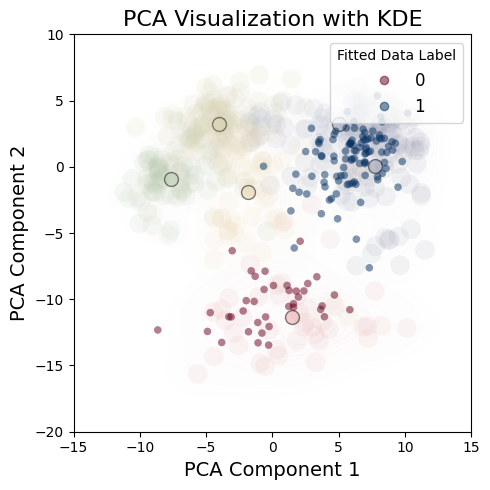

In [10]:

trajectory = euler_solver_sde(model, y0_new, num_steps=1000, num_genes=data.shape[1])
yf_fit = trajectory[-1].detach().numpy()
pca = PCA(n_components=2)
pca.fit(data)
data_pca = pca.transform(data)
yf_fit_pca = pca.transform(yf_fit)
gmm = GaussianMixture(n_components=2, random_state=0)
gmm.fit(yf_fit)
estimated_label = gmm.predict(yf_fit)
color_hex = {label: matplotlib.colors.to_hex(c) for label, c in color.items()}
color_hex.values()
color_hex_list = ['#b6c7a9', '#d6d1ae', '#9fa7bc', '#9092aa', '#ecb89c', '#ecd6b0', '#a4b496', '#e6a2a3']
color_hex_dict = {key: color_hex_list[i] for i, key in enumerate(sorted(color_hex.keys()))}


fig, ax = plt.subplots(figsize=(5, 5))

for label in label_unique:
    palette = sns.light_palette(color_hex_dict[label], as_cmap=True, n_colors=100)
    sns.kdeplot(x=data_pca[adata.obs['label']==label, 0], y=data_pca[adata.obs['label']==label, 1], 
                cmap=palette, fill=True, alpha=0.05, ax=ax)
    ax.scatter(data_pca[adata.obs['label']==label, 0], data_pca[adata.obs['label']==label, 1], 
               c=color_hex_dict[label], alpha=0.1, edgecolors='none', s=200)  # 增加点的大小和透明度
    ax.scatter(data_pca[adata.obs['label']==label, 0].mean(), data_pca[adata.obs['label']==label, 1].mean(), 
               c=color_hex_dict[label], alpha=0.5, edgecolors='black', s=100)  # 增加点的大小和透明度


fit_scatter = ax.scatter(yf_fit_pca[:, 0], yf_fit_pca[:, 1], c=estimated_label, cmap='RdBu', edgecolor='none', s=30, label='Fitted Data', alpha=0.5)  # 增加边框和点的大小
ax.legend(*fit_scatter.legend_elements(), title="Fitted Data Label", loc='upper right', fontsize=12)  # 添加图例
# ax.legend(loc='upper right', fontsize=12)  # 添加图例
ax.set_xlim(-15, 15)
ax.set_ylim(-20, 10)
ax.set_title('PCA Visualization with KDE', fontsize=16)  # 添加标题
ax.set_xlabel('PCA Component 1', fontsize=14)  # 添加x轴标签
ax.set_ylabel('PCA Component 2', fontsize=14)  # 添加y轴标签
ax.grid(False)  # 添加网格

plt.tight_layout()
plt.show()


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

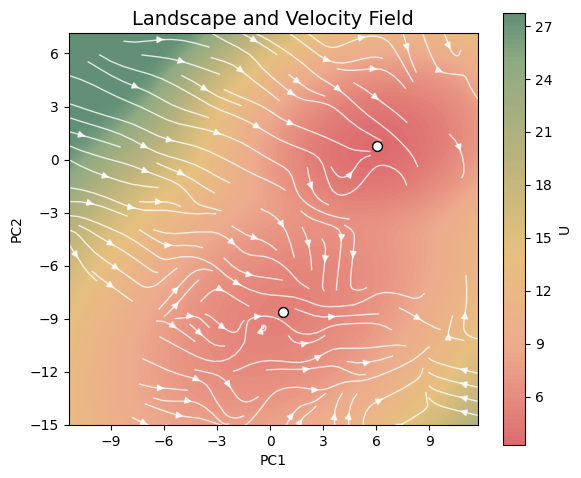

In [26]:
def create_smooth_gradient_cmap(color_list, n_bins=256):
    rgb_colors = [mcolors.to_rgb(color) for color in color_list]
    color_nodes = np.linspace(0, 1, len(rgb_colors))
    cmap = mcolors.LinearSegmentedColormap.from_list(
        'custom_gradient', 
        list(zip(color_nodes, rgb_colors)), 
        N=n_bins)
    return cmap


land_color_list = ['#dd6b6e','#e68c7f','#edaa8d','#eab685','#e6c07f','#cfba7c','#b9b37e','#a4ae7f','#8faa83','#608e76']
RdGr_cmap = create_smooth_gradient_cmap(land_color_list)


input_data = torch.tensor(data, dtype=torch.float32)
input_data_add = torch.cat((torch.randn(1000,20).abs()*15, torch.randn(1000,20)*15), dim=0)
yf_fit = euler_solver_sde(model, torch.cat((input_data, input_data_add), dim=0), num_steps=1000, num_genes=data.shape[1])[-1].detach().numpy()

yf_fit_pca = pca.transform(yf_fit)
n_gaussian = 2
gmm = GaussianMixture(n_components=n_gaussian, random_state=0)
gmm.fit(yf_fit_pca)


means = gmm.means_
covs = gmm.covariances_
weights = gmm.weights_

label = gmm.predict(yf_fit_pca)


fig, ax = plt.subplots(figsize=(6, 5))

x_range = np.linspace(-12, 12, 100)
y_range = np.linspace(-15, 9, 100)
X, Y = np.meshgrid(x_range, y_range)
gaussian_2d_list = []
for i in range(n_gaussian):
    gaussian_2d_i = stats.multivariate_normal(mean=means[i], cov=covs[i])
    Z = gaussian_2d_i.pdf(np.dstack([X, Y]))*weights[i]
    gaussian_2d_list.append(Z)
Z  = sum(gaussian_2d_list)
land = -np.log(Z + 1e-12)
contour = ax.contourf(X, Y, land, levels=100, cmap=RdGr_cmap) 
cbar = plt.colorbar(contour, ax=ax,label='U') 
cbar.ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))  
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True)) 
ax.scatter(means[:, 0], means[:, 1], alpha=1,s = 50,edgecolors='k',color='white')


# We use the vector field calculating function in Dynamo to provide a streamplot.
npzfile = np.load('example/Hepatocyte_Development_BF_vectorstreamplot.npz')
npzfile.files
X = npzfile['arr_0']
V = npzfile['arr_1']

ax.streamplot(X[0], X[1], V[0], V[1], color=[1, 1, 1, 0.8], linewidth=1)
ax.set_xlim(max(-12,X[0].min()), min(12,X[0].max()))
ax.set_ylim(max(-15,X[1].min()), min(9,X[1].max()))
ax.set_title('Landscape and Velocity Field', fontsize=14)
ax.set_aspect('equal')
ax.set_xlabel('PC1', fontsize=10)
ax.set_ylabel('PC2', fontsize=10)

plt.tight_layout()
plt.show()

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

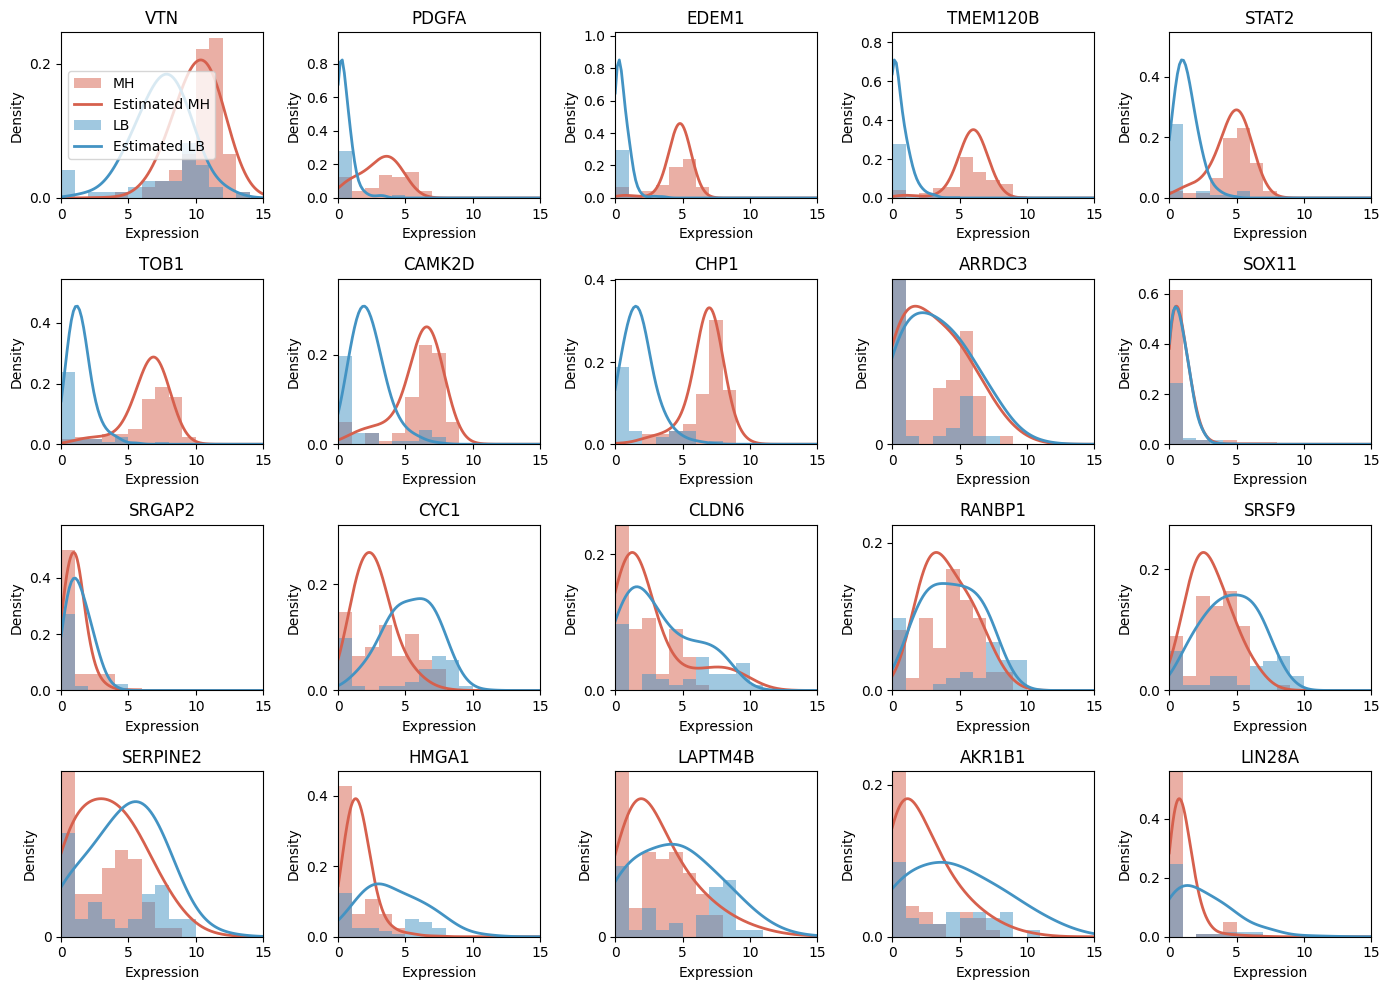

In [ ]:

gene_list = list(adata.var_names)
gmm_yf = GaussianMixture(n_components=2, random_state=0)
gmm_yf.fit(yf)

fit_label_yf = gmm_yf.predict(yf_fit)
weight_fit_0 = (fit_label_yf==0).sum()/len(fit_label_yf)
weight_fit_1 = (fit_label_yf==1).sum()/len(fit_label_yf)
weight_yf = gmm_yf.weights_
estimated_label_yf = gmm_yf.predict(yf)
fig,ax  = plt.subplots(4,5,figsize=(14,10))
ax = ax.flatten()
for i in range(yf.shape[1]):
    mask0 = estimated_label_yf == 0
    mask0_fit = fit_label_yf == 0
    mask1 = estimated_label_yf == 1
    mask1_fit = fit_label_yf == 1
    counts, bins, patches = ax[i].hist(yf[mask0,i],bins=range(0,15,1),label='MH',alpha=0.5,density=True,color=plt.cm.RdBu(0.2))
    for patch in patches:
        patch.set_height(patch.get_height() * weight_yf[0])
    kde = gaussian_kde(yf_fit[mask0_fit, i],bw_method=0.5)
    x = np.linspace(0, 15, 1000)
    density = kde(x)
    density_adjusted = density 

    ax[i].plot(x, density_adjusted, label='Estimated MH', color=plt.cm.RdBu(0.2),linewidth=2)
    upper_limit_1 = density_adjusted.max()*1.2
    counts, bins, patches = ax[i].hist(yf[mask1,i],bins=range(0,15,1),label='LB',alpha=0.5,density=True,color=plt.cm.RdBu(0.8))
    for patch in patches:
        patch.set_height(patch.get_height() * weight_yf[1])
    kde = gaussian_kde(yf_fit[mask1_fit, i],bw_method=0.5)
    x = np.linspace(0, 15, 100)
    density = kde(x)
    density_adjusted = density 
    upper_limit_2 = density_adjusted.max()*1.2
    ax[i].plot(x, density_adjusted, label='Estimated LB', color=plt.cm.RdBu(0.8),alpha=1,linewidth=2)

    ax[i].set_xlim(0, 15)
    ax[i].set_ylim(0, max(upper_limit_1, upper_limit_2))
    ax[i].set_title(gene_list[i])
    ax[i].set_xlabel('Expression')
    ax[i].set_ylabel('Density')
    ax[i].set_yticks(np.arange(0, max(upper_limit_1, upper_limit_2), 0.2)) 
    if i == 0:
        ax[i].legend()
plt.tight_layout()
plt.show()